In [2]:
import rdflib as rdf
from rdflib import Graph
from collections import Counter

# Load RDF Dataset

In [3]:
g = Graph()
g.parse("dataset/aifbfixed_complete.n3")

print("Graph loaded successfully!")
print("Number of triples:", len(g))

Graph loaded successfully!
Number of triples: 29226


# Count Unique Nodes

In [4]:
subjects = set()
objects = set()

for s, p, o in g:
    subjects.add(s)
    objects.add(o)

all_nodes = subjects.union(objects)

print("Unique subjects:", len(subjects))
print("Unique objects:", len(objects))
print("Total unique nodes:", len(all_nodes))

Unique subjects: 2829
Unique objects: 8096
Total unique nodes: 8285


# Predicates (Edges) Types & its Count

In [5]:
# Get all unique predicates (properties)
predicates = set()
for s, p, o in g:
    predicates.add(str(p))

# Count of Total Unique Predicates    
print(f"\nTotal unique predicates: {len(predicates)}")

# Show first 20 Properties
print("\nAll properties in dataset:")
for pred in sorted(predicates)[:20]:  # Show first 20
    print(f"  - {pred.split('#')[-1]}")  # Show readable name


Total unique predicates: 47

All properties in dataset:
  - abstract
  - address
  - affiliation
  - author
  - booktitle
  - carriedOutBy
  - carriesOut
  - chapter
  - dealtWithIn
  - edition
  - editor
  - employs
  - fax
  - financedBy
  - finances
  - hasProject
  - head
  - homepage
  - howpublished
  - isAbout


# Common Edges & Their Frequesncies

In [6]:
from collections import Counter

# Count how many times each property appears
predicates_count = Counter()
for s, p, o in g:
    predicates_count[str(p).split('#')[-1]] += 1

print("Top 15 most common properties:")
for pred, count in predicates_count.most_common(15):
    print(f"  {pred}: {count}")

Top 15 most common properties:
  type: 4174
  publication: 4163
  author: 3986
  isAbout: 2477
  name: 1302
  year: 1227
  title: 1227
  publishes: 1217
  hasProject: 952
  projectInfo: 952
  booktitle: 765
  month: 759
  isWorkedOnBy: 571
  pages: 548
  abstract: 534


# All Subject Types & their Counts

In [7]:
# What are the main entities?
rdf_type = rdf.term.URIRef("http://www.w3.org/1999/02/22-rdf-syntax-ns#type")

entity_types = Counter()
for s, p, o in g.triples((None, rdf_type, None)):
    entity_types[str(o).split('#')[-1]] += 1

print("Entity types in dataset:")
for etype, count in entity_types.most_common(20):
    print(f"  {etype}: {count}")

Entity types in dataset:
  Publication: 1222
  Person: 1045
  InProceedings: 687
  TechnicalReport: 169
  Article: 161
  Restriction: 152
  ResearchTopic: 146
  InCollection: 87
  Project: 78
  PhDStudent: 65
  Class: 55
  Misc: 51
  Proceedings: 49
  ObjectProperty: 42
  DatatypeProperty: 31
  Organization: 28
  Book: 23
  Lecturer: 6
  Undergraduate: 6
  ResearchGroup: 5


# Sample Triples

In [8]:
# Show first 10 triples
print("Sample triples from dataset:")
for i, (s, p, o) in enumerate(g):
    if i >= 10:
        break
    print(f"{str(s)[-30:]} → {str(p).split('#')[-1]} → {str(o)[-40:]}")

Sample triples from dataset:
wPublikationOWL/id1159instance → author → ionen/viewExternerAutorOWL/id148instance
iewPublikationOWL/id83instance → booktitle → ng Symposium 2003, Stanford, March 24-26
nen/viewPersonOWL/id57instance → publication → ationen/viewPublikationOWL/id578instance
wPublikationOWL/id1090instance → type → //swrc.ontoware.org/ontology#Publication
ewPublikationOWL/id796instance → isAbout → ete/viewForschungsgebietOWL/id68instance
ewPublikationOWL/id780instance → booktitle → tion and Modelling Conference (ESMc2004)
ewPublikationOWL/id599instance → author → ionen/viewExternerAutorOWL/id177instance
n/viewPersonOWL/id2049instance → worksAtProject → e.de/Projekte/viewProjektOWL/id2instance
ub1bL355C18 → type → ttp://www.w3.org/2002/07/owl#Restriction
ExternerAutorOWL/id712instance → publication → tionen/viewPublikationOWL/id1161instance


# Degree Analysis

For Discover

hub nodes
, influential entities
, noisy nodes

This affects GNN message passing.

In [9]:
degree_counter = Counter()

for s, p, o in g:
    degree_counter[s] += 1
    degree_counter[o] += 1

print("\nTop connected nodes:\n")

for node, degree in degree_counter.most_common(10):
    print(degree, node)


Top connected nodes:

1247 http://swrc.ontoware.org/ontology#Publication
1074 http://swrc.ontoware.org/ontology#Person
1054 http://www.aifb.uni-karlsruhe.de/Forschungsgruppen/viewForschungsgruppeOWL/id3instance
700 http://swrc.ontoware.org/ontology#InProceedings
469 http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id6instance
461 http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id57instance
379 http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id20instance
355 http://www.aifb.uni-karlsruhe.de/Projekte/viewProjektOWL/id42instance
320 http://www.aifb.uni-karlsruhe.de/Forschungsgebiete/viewForschungsgebietOWL/id79instance
295 http://www.aifb.uni-karlsruhe.de/Forschungsgruppen/viewForschungsgruppeOWL/id1instance


# Find Meta Path for Predicate " Publication "

In [10]:
for s, p, o in g:
    if "publication" in str(p).lower():
        print(s, p, o)
        break

http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id57instance http://swrc.ontoware.org/ontology#publication http://www.aifb.uni-karlsruhe.de/Publikationen/viewPublikationOWL/id578instance


In [11]:
import pandas as pd

triples = []

for s, p, o in g:
    triples.append([str(s), str(p), str(o)])

df = pd.DataFrame(triples, columns=["subject", "predicate", "object"])

print(df.head())

                                             subject  \
0  http://www.aifb.uni-karlsruhe.de/Publikationen...   
1  http://www.aifb.uni-karlsruhe.de/Publikationen...   
2  http://www.aifb.uni-karlsruhe.de/Personen/view...   
3  http://www.aifb.uni-karlsruhe.de/Publikationen...   
4  http://www.aifb.uni-karlsruhe.de/Publikationen...   

                                         predicate  \
0         http://swrc.ontoware.org/ontology#author   
1      http://swrc.ontoware.org/ontology#booktitle   
2    http://swrc.ontoware.org/ontology#publication   
3  http://www.w3.org/1999/02/22-rdf-syntax-ns#type   
4        http://swrc.ontoware.org/ontology#isAbout   

                                              object  
0  http://www.aifb.uni-karlsruhe.de/Publikationen...  
1  Agent-mediated Knowledge Management - AMKM-200...  
2  http://www.aifb.uni-karlsruhe.de/Publikationen...  
3      http://swrc.ontoware.org/ontology#Publication  
4  http://www.aifb.uni-karlsruhe.de/Forschungsgeb...  


# Graph - Predicates Distribution

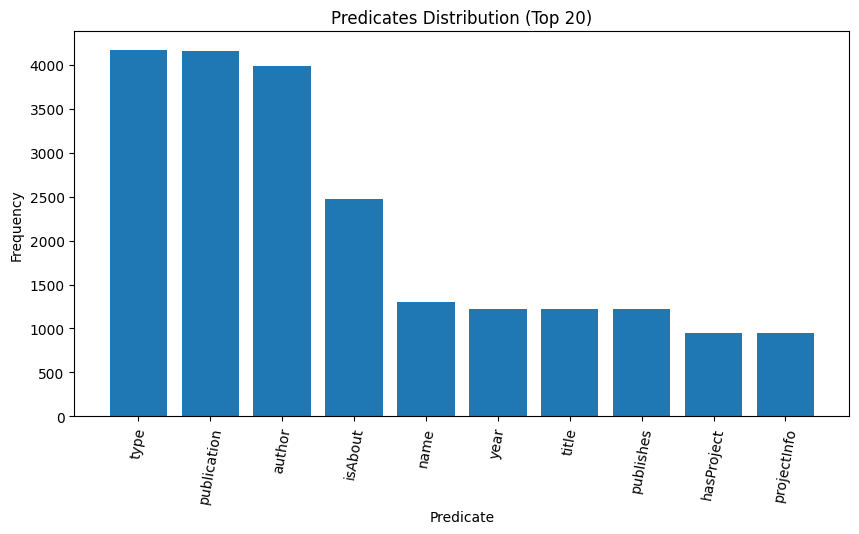

In [12]:
import matplotlib.pyplot as plt

top_preds = predicates_count.most_common(10)

names = [x[0].split("/")[-1] for x in top_preds]
counts = [x[1] for x in top_preds]

plt.figure(figsize=(10,5))
plt.bar(names, counts)

plt.xticks(rotation=80)
plt.title("Predicates Distribution (Top 20)")
plt.xlabel("Predicate")
plt.ylabel("Frequency")
plt.show()

# Graph - Node type Distribution


Node Type Distribution:

1222 http://swrc.ontoware.org/ontology#Publication
1045 http://swrc.ontoware.org/ontology#Person
687 http://swrc.ontoware.org/ontology#InProceedings
169 http://swrc.ontoware.org/ontology#TechnicalReport
161 http://swrc.ontoware.org/ontology#Article
152 http://www.w3.org/2002/07/owl#Restriction
146 http://swrc.ontoware.org/ontology#ResearchTopic
87 http://swrc.ontoware.org/ontology#InCollection
78 http://swrc.ontoware.org/ontology#Project
65 http://swrc.ontoware.org/ontology#PhDStudent
55 http://www.w3.org/2002/07/owl#Class
51 http://swrc.ontoware.org/ontology#Misc
49 http://swrc.ontoware.org/ontology#Proceedings
42 http://www.w3.org/2002/07/owl#ObjectProperty
31 http://www.w3.org/2002/07/owl#DatatypeProperty
28 http://swrc.ontoware.org/ontology#Organization
23 http://swrc.ontoware.org/ontology#Book
6 http://swrc.ontoware.org/ontology#Lecturer
6 http://swrc.ontoware.org/ontology#Undergraduate
5 http://swrc.ontoware.org/ontology#ResearchGroup
5 http://swrc.ontow

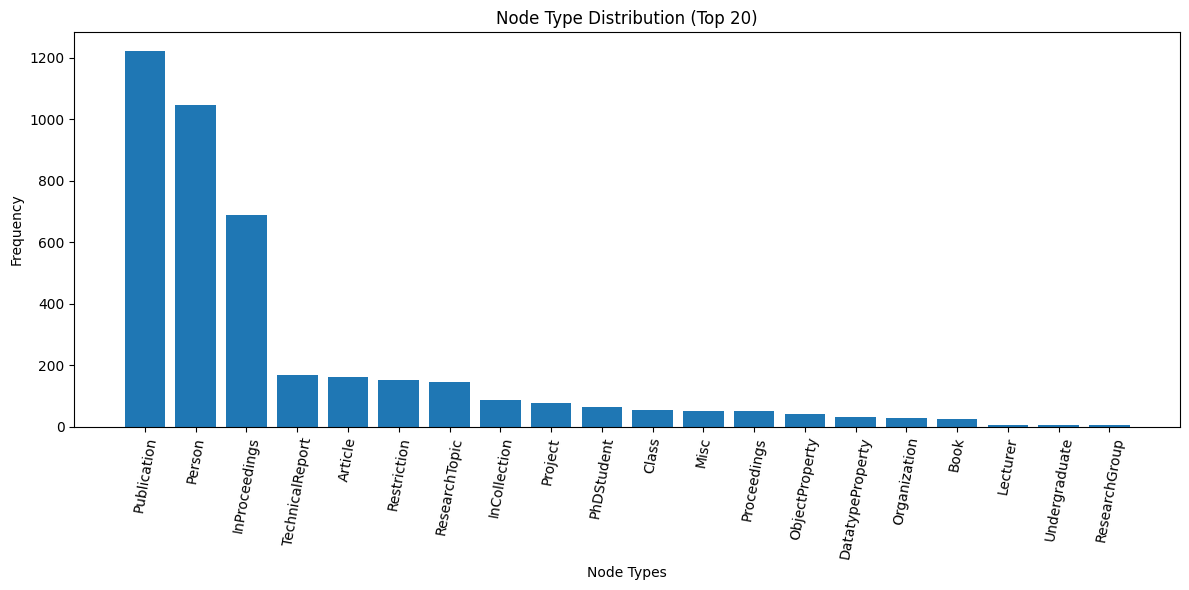

In [13]:
type_counter = Counter()

for s, p, o in g:
    
    # rdf:type relation
    if p == rdf.RDF.type:
        type_counter[str(o)] += 1


# Count Nodes
print("\nNode Type Distribution:\n")

for node_type, count in type_counter.most_common():
    print(count, node_type)

# Prepare data for Ploting
labels = []
counts = []

for node_type, count in type_counter.most_common(20):
    
    # Short readable label
    short_name = node_type.split("/")[-1]
    short_name = short_name.split("#")[-1]

    labels.append(short_name)
    counts.append(count)

# Bar Graph 
plt.figure(figsize=(12,6))

plt.bar(labels, counts)
plt.title("Node Type Distribution (Top 20)")
plt.xlabel("Node Types")
plt.ylabel("Frequency")
plt.xticks(rotation=80)

plt.tight_layout()
plt.show()

# Label Distribution of Research Group

In [14]:
# Find Correct Predicate Label
predicate_counter = Counter()

for s, p, o in g:
    predicate_counter[str(p)] += 1

for pred, count in predicate_counter.most_common(30):
    print(count, pred)

4163 http://swrc.ontoware.org/ontology#publication
4124 http://www.w3.org/1999/02/22-rdf-syntax-ns#type
3986 http://swrc.ontoware.org/ontology#author
2477 http://swrc.ontoware.org/ontology#isAbout
1302 http://swrc.ontoware.org/ontology#name
1227 http://swrc.ontoware.org/ontology#year
1227 http://swrc.ontoware.org/ontology#title
1217 http://swrc.ontoware.org/ontology#publishes
952 http://swrc.ontoware.org/ontology#hasProject
952 http://swrc.ontoware.org/ontology#projectInfo
765 http://swrc.ontoware.org/ontology#booktitle
759 http://swrc.ontoware.org/ontology#month
571 http://swrc.ontoware.org/ontology#isWorkedOnBy
548 http://swrc.ontoware.org/ontology#pages
534 http://swrc.ontoware.org/ontology#abstract
357 http://swrc.ontoware.org/ontology#dealtWithIn
339 http://swrc.ontoware.org/ontology#member
311 http://swrc.ontoware.org/ontology#volume
298 http://swrc.ontoware.org/ontology#series
239 http://swrc.ontoware.org/ontology#homepage
227 http://swrc.ontoware.org/ontology#phone
227 http://s


Label Distribution:

73 http://www.aifb.uni-karlsruhe.de/Forschungsgruppen/viewForschungsgruppeOWL/id1instance
28 http://www.aifb.uni-karlsruhe.de/Forschungsgruppen/viewForschungsgruppeOWL/id2instance
60 http://www.aifb.uni-karlsruhe.de/Forschungsgruppen/viewForschungsgruppeOWL/id3instance
16 http://www.aifb.uni-karlsruhe.de/Forschungsgruppen/viewForschungsgruppeOWL/id4instance
1 http://www.aifb.uni-karlsruhe.de/Forschungsgruppen/viewForschungsgruppeOWL/id5instance


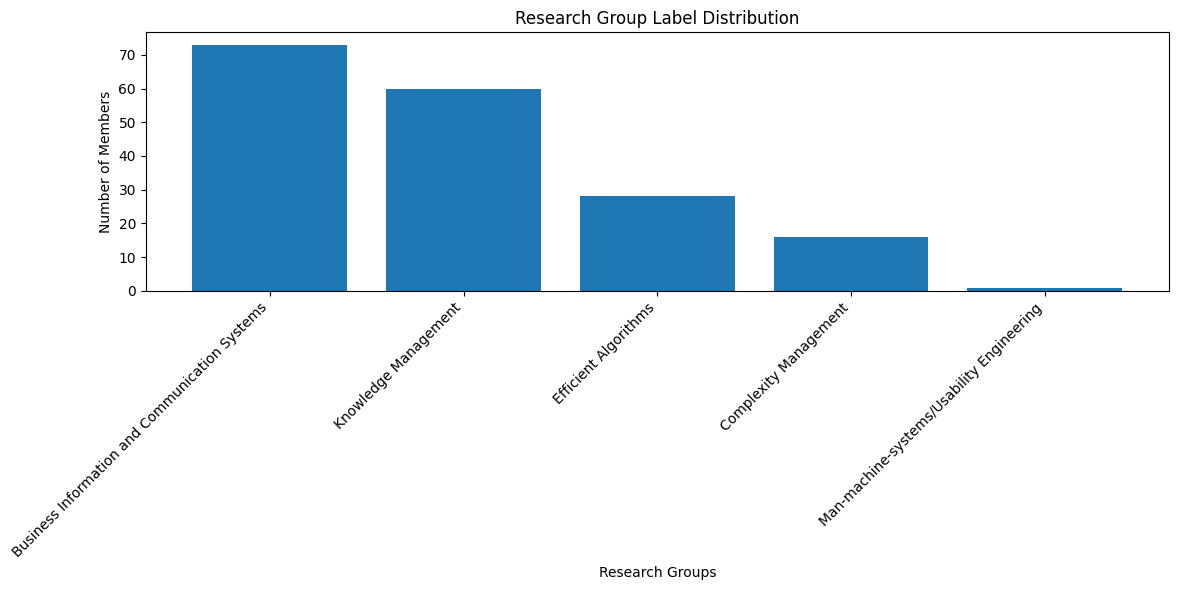

In [15]:
TARGET_PREDICATE = "http://swrc.ontoware.org/ontology#affiliation"
swrc_name = rdf.term.URIRef("http://swrc.ontoware.org/ontology#name")

# Count Labels
label_counter = Counter()
research_groups = {}

for s, p, o in g:
    if str(p) == TARGET_PREDICATE:
        label_counter[str(o)] += 1
        research_groups[str(o)] = None

print("\nLabel Distribution:\n")

for label, count in label_counter.items():
    print(count, label)

# Get research group names from swrc:name property
for group_uri in research_groups.keys():
    group_ref = rdf.term.URIRef(group_uri)
    
    # Get the name from swrc:name
    names = list(g.objects(group_ref, swrc_name))
    if names:
        research_groups[group_uri] = str(names[0])
    else:
        # Fallback to URI fragment if no name found
        short_name = group_uri.split("/")[-1]
        short_name = short_name.split("#")[-1]
        research_groups[group_uri] = short_name

# Prepare Data for Visualization
labels = []
counts = []

for group_uri, count in sorted(label_counter.items(), key=lambda x: x[1], reverse=True):
    labels.append(research_groups[group_uri])
    counts.append(count)

# Plot Bar Graph
plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.title("Research Group Label Distribution")
plt.xlabel("Research Groups")
plt.ylabel("Number of Members")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
